# ch281 — Regression

*(Uses matrix algebra from ch181 — Linear Regression via Matrix Algebra; gradient descent from ch213; correlation from ch280)*

## 1. The Regression Problem

Given pairs $(x_i, y_i)$, find the function $f$ that best explains $y$ in terms of $x$:
$$y_i = f(x_i) + \epsilon_i$$

For linear regression: $f(x) = \beta_0 + \beta_1 x$. We want the values $\beta_0, \beta_1$ that minimize the sum of squared residuals.

## 2. Simple Linear Regression — Closed Form

The OLS (Ordinary Least Squares) solution:

$$\hat{\beta}_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2} = \frac{\text{Cov}(x,y)}{\text{Var}(x)}, \quad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

Slope:     manual=2.5230, scipy=2.5230
Intercept: manual=2.8461, scipy=2.8461


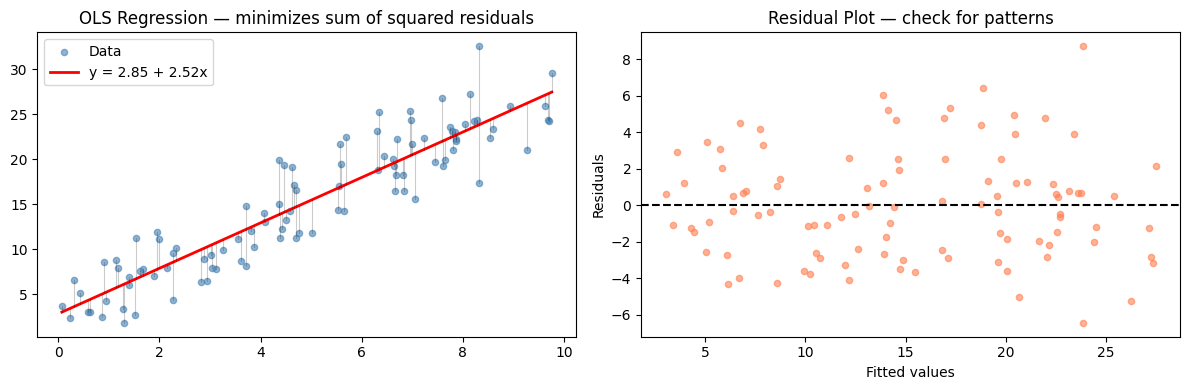

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)
n = 100
x = rng.uniform(0, 10, n)
y = 3 + 2.5 * x + rng.normal(0, 3, n)

def simple_ols(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    """Returns (intercept, slope) via closed-form OLS."""
    x_c = x - x.mean()
    slope     = np.dot(x_c, y - y.mean()) / np.dot(x_c, x_c)
    intercept = y.mean() - slope * x.mean()
    return intercept, slope

b0, b1 = simple_ols(x, y)
y_hat  = b0 + b1 * x

# Validate
slope_sp, intercept_sp, r, p, se = stats.linregress(x, y)
print(f"Slope:     manual={b1:.4f}, scipy={slope_sp:.4f}")
print(f"Intercept: manual={b0:.4f}, scipy={intercept_sp:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(x, y, s=20, alpha=0.6, color='steelblue', label='Data')
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, b0 + b1*x_line, 'r-', lw=2, label=f'y = {b0:.2f} + {b1:.2f}x')
for xi, yi, yhi in zip(x, y, y_hat):
    ax.plot([xi, xi], [yi, yhi], 'k-', alpha=0.2, lw=0.8)
ax.set_title('OLS Regression — minimizes sum of squared residuals')
ax.legend()

residuals = y - y_hat
ax = axes[1]
ax.scatter(y_hat, residuals, s=20, alpha=0.6, color='coral')
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Fitted values'); ax.set_ylabel('Residuals')
ax.set_title('Residual Plot — check for patterns')

plt.tight_layout()
plt.show()

## 3. Multiple Linear Regression — Matrix Form

For multiple predictors, the model is $\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}$ where $\mathbf{X}$ is the design matrix.

The normal equations give the closed-form solution:
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

*(Derived in ch181 — Linear Regression via Matrix Algebra)*

In [2]:
def multiple_ols(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    OLS via normal equations: beta = (X^T X)^{-1} X^T y
    X should include a column of ones for the intercept.
    """
    return np.linalg.lstsq(X, y, rcond=None)[0]  # lstsq is numerically stable

def add_intercept(X: np.ndarray) -> np.ndarray:
    return np.column_stack([np.ones(len(X)), X])

def r_squared(y: np.ndarray, y_hat: np.ndarray) -> float:
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    return 1 - ss_res / ss_tot

def adjusted_r_squared(y, y_hat, n_params):
    n = len(y)
    r2 = r_squared(y, y_hat)
    return 1 - (1 - r2) * (n - 1) / (n - n_params - 1)

# Multivariate example
n = 200
x1 = rng.normal(5, 2, n)
x2 = rng.normal(10, 3, n)
x3 = rng.normal(0, 1, n)   # noise feature
y_multi = 2 + 1.5*x1 - 0.8*x2 + rng.normal(0, 2, n)

X_multi  = add_intercept(np.column_stack([x1, x2, x3]))
beta_hat = multiple_ols(X_multi, y_multi)
y_pred   = X_multi @ beta_hat

print("True coefficients:    [2.0, 1.5, -0.8, 0.0]")
print(f"Estimated:            [{', '.join(f'{b:.3f}' for b in beta_hat)}]")
print(f"R²:           {r_squared(y_multi, y_pred):.4f}")
print(f"Adjusted R²:  {adjusted_r_squared(y_multi, y_pred, n_params=3):.4f}")

# Compare with sklearn
from sklearn.linear_model import LinearRegression
lr = LinearRegression(fit_intercept=False)
lr.fit(X_multi, y_multi)
print(f"\nsklearn coefs: [{', '.join(f'{c:.3f}' for c in lr.coef_)}]")
print(f"Match: {np.allclose(beta_hat, lr.coef_, atol=1e-6)}")

True coefficients:    [2.0, 1.5, -0.8, 0.0]
Estimated:            [2.787, 1.322, -0.794, 0.052]
R²:           0.7616
Adjusted R²:  0.7579

sklearn coefs: [2.787, 1.322, -0.794, 0.052]
Match: True


## 4. Assumptions and Diagnostics

OLS guarantees are valid only when:
1. **Linearity**: $E[y|x] = X\beta$
2. **Independence**: observations are i.i.d.
3. **Homoskedasticity**: $\text{Var}(\epsilon_i)$ is constant
4. **Normality of residuals**: for inference (CIs, p-values)
5. **No multicollinearity**: $X^TX$ must be invertible

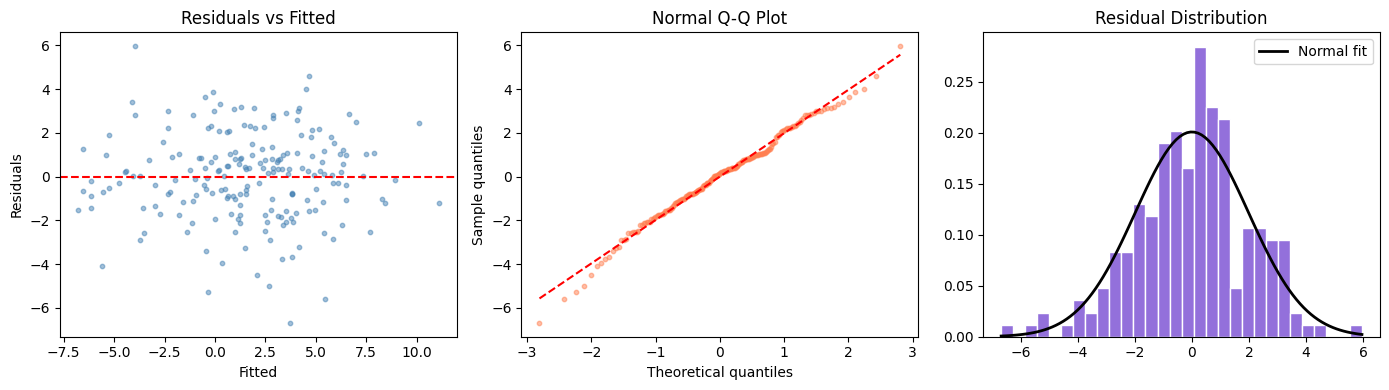

In [3]:
# Regression diagnostic plots
residuals = y_multi - y_pred

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Residuals vs fitted
axes[0].scatter(y_pred, residuals, s=10, alpha=0.5, color='steelblue')
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Fitted'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# 2. Q-Q plot
sorted_res = np.sort(residuals)
n_pts = len(sorted_res)
theoretical_q = stats.norm.ppf((np.arange(1, n_pts+1) - 0.5) / n_pts)
axes[1].scatter(theoretical_q, sorted_res, s=10, alpha=0.5, color='coral')
mn, mx = theoretical_q.min(), theoretical_q.max()
axes[1].plot([mn, mx], [mn*residuals.std() + residuals.mean(),
                        mx*residuals.std() + residuals.mean()], 'r--')
axes[1].set_xlabel('Theoretical quantiles'); axes[1].set_ylabel('Sample quantiles')
axes[1].set_title('Normal Q-Q Plot')

# 3. Residuals histogram
axes[2].hist(residuals, bins=30, color='mediumpurple', edgecolor='white', density=True)
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
axes[2].plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
             'k-', lw=2, label='Normal fit')
axes[2].set_title('Residual Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. What Comes Next

R² tells you how much variance the model explains on the *training data*. This is not the same as how well it will perform on new data. **ch282 — Model Evaluation** develops the metrics needed to assess true generalization. **ch283 — Overfitting** explains precisely why training R² is an optimistic estimate.

The regression framework generalizes to classification in **ch294** via logistic regression, which replaces the linear output with a sigmoid transformation *(introduced in ch063 — Sigmoid Functions)*.